# 06 — How we fit the NHANES LSM distribution: candidate methods, side by side

This notebook is a team-facing tour. Notebook 04 picked a single method (F4-calibrated lognormal). A team member produced an alternative table using a different method (log-moment match on a larger pooled NHANES sample). This notebook puts both side-by-side against the empirical data, walks through the four candidate methods we considered, and shows **why F4 calibration is the one the project priorities** — even when another method has a smaller KS distance on the bulk of the distribution.

**Three things this notebook should make obvious:**
1. The team member's table is consistent with NHANES P_LUX + LUX_L pooled (2017 – Aug 2023). The data difference (compared to notebook 04, which used P_LUX alone) is **pooling**, not weighting or filtering.
2. F4-calibration anchors the right tail (the F4 share, P[LSM ≥ 12.5 kPa]) by construction. Log-moment match — and the moment-match, gamma, and Weibull alternatives — don't, and they miss the empirical F4 share by absolute differences of up to several percentage points in some cells.
3. For the cirrhosis-EMR routing rule in this project, the F4 share is the load-bearing quantity. Getting the bulk right at the cost of the tail is the wrong trade.


## 1. Setup — pool P_LUX (2017–Mar 2020) and LUX_L (2021–Aug 2023)

The team member's table reproduces best against the pooled sample with each cycle's MEC weight halved. Notebook 04 used P_LUX alone; this notebook uses the larger pooled sample so the picture is directly comparable to the team member's CSV.


In [1]:
import os, sys, urllib.request, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

ROOT = Path(os.path.abspath(os.path.join('..')))
DATA = ROOT / 'data'
DERIVED = DATA / 'derived'
DERIVED.mkdir(parents=True, exist_ok=True)
RAW_P = DATA / 'raw' / 'nhanes' / '2017_2020_prepandemic'
RAW_L = DATA / 'raw' / 'nhanes' / '2021_2023'
RAW_P.mkdir(parents=True, exist_ok=True)
RAW_L.mkdir(parents=True, exist_ok=True)

# fetch source XPTs only if missing
SRC = {
    RAW_P / 'P_DEMO.xpt': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt',
    RAW_P / 'P_LUX.xpt':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_LUX.xpt',
    RAW_L / 'DEMO_L.xpt': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
    RAW_L / 'LUX_L.xpt':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/LUX_L.xpt',
}
for out, url in SRC.items():
    if out.exists():
        continue
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=120) as r:
        out.write_bytes(r.read())

def parse(demo_path, lux_path, wt_col, cycle):
    d = pd.read_sas(demo_path)[['SEQN', 'RIAGENDR', 'RIDAGEYR', wt_col]]
    l = pd.read_sas(lux_path)[['SEQN', 'LUXSMED', 'LUAXSTAT']]
    df = d.merge(l, on='SEQN', how='left')
    df['sex'] = df['RIAGENDR'].map({1.0: 'Male', 2.0: 'Female'})
    df['age_years'] = df['RIDAGEYR'].astype(float)
    df['exam_complete'] = df['LUAXSTAT'] == 1.0
    df['LSM_KPA'] = df['LUXSMED']
    df['MEC_WT']  = df[wt_col].astype(float)
    df['cycle']   = cycle
    return df[['SEQN','cycle','sex','age_years','MEC_WT','LSM_KPA','exam_complete']]

p = parse(RAW_P / 'P_DEMO.xpt', RAW_P / 'P_LUX.xpt', 'WTMECPRP', '2017_2020')
l = parse(RAW_L / 'DEMO_L.xpt', RAW_L / 'LUX_L.xpt', 'WTMEC2YR', '2021_2023')
pool = pd.concat([p, l], ignore_index=True)
pool['MEC_WT_POOL'] = pool['MEC_WT'] * 0.5  # halve each cycle, standard NCHS practice

m = (pool['exam_complete'].fillna(False)
     & pool['LSM_KPA'].notna()
     & pool['MEC_WT'].fillna(0).gt(0))
ana = pool[m].copy()
print(f'pooled MEC-examined adults with LSM: n = {len(ana):,}')
print(ana.groupby('cycle').size().to_string())


pooled MEC-examined adults with LSM: n = 15,303
cycle
2017_2020    9023
2021_2023    6280


## 2. Empirical truth — per-(sex, 5-yr age band) summary

The simulation needs distributions per (sex, 5-yr age band). For each cell we compute, on the pooled sample:

- **mean, SD** — arithmetic, in kPa
- **median** — anchors the F4-calibrated lognormal
- **log mean, log SD** — moments on log(kPa); these are what the team member's CSV records
- **F4 share** — P[LSM ≥ 12.5 kPa]; the load-bearing quantity for cirrhosis-EMR routing


In [2]:
def w_mean(y, w): return float(np.average(y, weights=w))
def w_sd(y, w):
    mu = w_mean(y, w)
    return float(np.sqrt(np.average((y - mu)**2, weights=w)))
def w_quantile(y, w, q):
    o = np.argsort(y); ys, ws = y[o], w[o]
    cw = np.cumsum(ws) / ws.sum()
    return float(np.interp(q, cw, ys))
def w_share_above(y, w, c):
    return float(np.average((y >= c).astype(float), weights=w))

F4 = 12.5
edges = list(range(25, 85, 5)) + [85]

rows = []
for sex in ['Female', 'Male']:
    for a0, a1 in zip(edges[:-1], edges[1:]):
        sub = ana[(ana['sex'] == sex)
                  & (ana['age_years'] >= a0)
                  & (ana['age_years'] < a1)]
        if len(sub) < 30:
            continue
        y = sub['LSM_KPA'].values.astype(float)
        w = sub['MEC_WT_POOL'].values.astype(float)
        rows.append({
            'sex': sex, 'age5': a0, 'n': len(sub),
            'mean':       w_mean(y, w),
            'sd':         w_sd(y, w),
            'median':     w_quantile(y, w, 0.5),
            'log_mean':   w_mean(np.log(y), w),
            'log_sd':     w_sd(np.log(y), w),
            'f4':         w_share_above(y, w, F4),
        })
emp = pd.DataFrame(rows)
print(emp.round(3).to_string(index=False))


   sex  age5   n  mean    sd  median  log_mean  log_sd    f4
Female    25 456 4.830 1.922   4.500     1.520   0.313 0.006
Female    30 522 5.262 6.085   4.300     1.522   0.402 0.017
Female    35 526 5.209 3.768   4.600     1.561   0.373 0.021
Female    40 520 5.156 2.699   4.500     1.560   0.367 0.017
Female    45 474 5.276 2.439   4.600     1.592   0.350 0.026
Female    50 524 5.618 4.133   4.900     1.621   0.403 0.029
Female    55 619 6.638 7.032   5.200     1.719   0.483 0.064
Female    60 778 5.776 5.120   4.700     1.626   0.424 0.031
Female    65 659 5.800 3.916   5.000     1.647   0.421 0.040
Female    70 485 5.882 4.083   4.926     1.657   0.426 0.038
Female    75 319 5.591 3.117   4.911     1.634   0.380 0.028
Female    80 328 5.621 2.948   5.000     1.649   0.358 0.031
  Male    25 410 5.575 4.665   5.100     1.627   0.349 0.016
  Male    30 500 5.775 4.151   5.000     1.657   0.377 0.035
  Male    35 406 5.793 5.188   4.966     1.637   0.406 0.025
  Male    40 474 6.102 4

## 3. Verify: the team member's CSV is the pooled NHANES log-moment match

Load the table the team member committed at `vivarium_csu_mace_rct/src/.../nhanes_rf_distributions.csv`. Its `LSM` column is the weighted mean of log(LSM_KPA); `LSM_sd` is the weighted SD of log(LSM_KPA). Both should match the `log_mean` and `log_sd` columns we just computed, up to small residuals from weight handling.


In [3]:
COLLEAGUE = (ROOT.parent / 'vivarium_csu_mace_rct'
             / 'src' / 'vivarium_csu_mace_rct' / 'data'
             / 'nhanes_rf_distributions.csv')
coll = pd.read_csv(COLLEAGUE).rename(columns={'Sex': 'sex'})[
    ['age5', 'sex', 'LSM', 'LSM_sd']
]
chk = emp.merge(coll, on=['sex', 'age5'], how='inner')
chk['d_log_mean'] = chk['log_mean'] - chk['LSM']
chk['d_log_sd']   = chk['log_sd']   - chk['LSM_sd']
rms_m = float(np.sqrt(np.mean(chk['d_log_mean']**2)))
rms_s = float(np.sqrt(np.mean(chk['d_log_sd']**2)))
print(f'RMS residual log_mean = {rms_m:.3f}, log_sd = {rms_s:.3f}')
print('  (compare against ~0.045 / 0.069 if we used P_LUX alone — pooling halves it)')
print()
print(chk[['sex', 'age5', 'n', 'log_mean', 'LSM',
           'log_sd', 'LSM_sd', 'd_log_mean', 'd_log_sd']]
      .round(3).to_string(index=False))


RMS residual log_mean = 0.018, log_sd = 0.026
  (compare against ~0.045 / 0.069 if we used P_LUX alone — pooling halves it)

   sex  age5   n  log_mean   LSM  log_sd  LSM_sd  d_log_mean  d_log_sd
Female    25 456     1.520 1.534   0.313   0.335      -0.014    -0.022
Female    30 522     1.522 1.537   0.402   0.408      -0.014    -0.007
Female    35 526     1.561 1.573   0.373   0.390      -0.013    -0.017
Female    40 520     1.560 1.566   0.367   0.383      -0.006    -0.016
Female    45 474     1.592 1.629   0.350   0.399      -0.036    -0.049
Female    50 524     1.621 1.640   0.403   0.429      -0.019    -0.027
Female    55 619     1.719 1.726   0.483   0.482      -0.007     0.001
Female    60 778     1.626 1.643   0.424   0.434      -0.017    -0.010
Female    65 659     1.647 1.661   0.421   0.436      -0.014    -0.014
Female    70 485     1.657 1.672   0.426   0.454      -0.014    -0.029
Female    75 319     1.634 1.646   0.380   0.403      -0.012    -0.023
Female    80 328     1.

## 4. The candidate fits

For each cell × candidate we fit a closed-form distribution and ask: what arithmetic mean, what SD, and most importantly **what F4 share** does that fit imply?

| # | Method | What it minimises | Tail behaviour |
| --- | --- | --- | --- |
| (1) | **Log-moment match** (team member) | µ, σ = sample mean and SD of log(LSM) | Whatever falls out — no explicit tail anchor |
| (2) | **Arithmetic moment match** | back-solve (µ, σ) so the lognormal has the empirical mean and SD | Whatever falls out |
| (3) | **Gamma MoM** | shape k = (mean/sd)², scale θ = sd²/mean | Different family — lighter right tail than lognormal |
| (4) | **Weibull MLE** | maximum likelihood (weighted) | Even lighter right tail at typical fits |
| (5) | **F4-calibrated lognormal** (notebook 04) | µ = log(empirical median), σ chosen so P[X ≥ 12.5] = empirical F4 share | F4 share matches by construction |

The first four are agnostic to the cutoff that matters. The fifth pins the cutoff and lets the bulk fall where it may.


In [4]:
def fit_log_mm(y, w):
    log_y = np.log(y)
    mu = w_mean(log_y, w)
    sg = w_sd(log_y, w)
    return mu, sg

def fit_arith_mm(mean, sd):
    sigma2 = np.log(1 + (sd / mean) ** 2)
    mu = np.log(mean ** 2 / np.sqrt(mean ** 2 + sd ** 2))
    return mu, float(np.sqrt(sigma2))

def fit_gamma_mom(mean, sd):
    k  = (mean / sd) ** 2
    th = sd ** 2 / mean
    return k, th

def fit_weibull_mle(y, w):
    from scipy.optimize import minimize
    init = stats.weibull_min.fit(y, floc=0)
    def negll(p):
        c, s = p
        if c <= 0 or s <= 0:
            return 1e12
        return -np.sum(w * stats.weibull_min.logpdf(y, c, scale=s))
    r = minimize(negll, [init[0], init[2]], method='Nelder-Mead')
    return float(r.x[0]), float(r.x[1])

def fit_lognorm_f4(median, target_f4, cutoff=F4):
    mu = np.log(median)
    if not (0 < target_f4 < 1):
        return mu, np.nan
    z = stats.norm.ppf(1 - target_f4)
    if z <= 0:
        return mu, np.nan
    return mu, max(0.0, (np.log(cutoff) - mu) / z)

def weighted_ks(y, w, cdf):
    o = np.argsort(y); ys, ws = y[o], w[o]
    emp_cdf = np.cumsum(ws) / ws.sum()
    return float(np.max(np.abs(emp_cdf - cdf(ys))))

fit_rows = []
for _, r in emp.iterrows():
    sub = ana[(ana['sex'] == r['sex'])
              & (ana['age_years'] >= r['age5'])
              & (ana['age_years'] < r['age5'] + 5)]
    y = sub['LSM_KPA'].values.astype(float)
    w = sub['MEC_WT_POOL'].values.astype(float)

    mu1, sg1 = fit_log_mm(y, w)
    cdf1 = lambda v, mu=mu1, sg=sg1: stats.lognorm.cdf(v, sg, scale=np.exp(mu))
    f4_1 = 1 - cdf1(F4); ks_1 = weighted_ks(y, w, cdf1)

    mu2, sg2 = fit_arith_mm(r['mean'], r['sd'])
    cdf2 = lambda v, mu=mu2, sg=sg2: stats.lognorm.cdf(v, sg, scale=np.exp(mu))
    f4_2 = 1 - cdf2(F4); ks_2 = weighted_ks(y, w, cdf2)

    k3, th3 = fit_gamma_mom(r['mean'], r['sd'])
    cdf3 = lambda v, k=k3, th=th3: stats.gamma.cdf(v, k, scale=th)
    f4_3 = 1 - cdf3(F4); ks_3 = weighted_ks(y, w, cdf3)

    c4, s4 = fit_weibull_mle(y, w)
    cdf4 = lambda v, c=c4, s=s4: stats.weibull_min.cdf(v, c, scale=s)
    f4_4 = 1 - cdf4(F4); ks_4 = weighted_ks(y, w, cdf4)

    mu5, sg5 = fit_lognorm_f4(r['median'], r['f4'])
    cdf5 = lambda v, mu=mu5, sg=sg5: stats.lognorm.cdf(v, sg, scale=np.exp(mu))
    f4_5 = (1 - cdf5(F4)) if not np.isnan(sg5) else np.nan
    ks_5 = weighted_ks(y, w, cdf5) if not np.isnan(sg5) else np.nan
    mean_5 = float(np.exp(mu5 + sg5 ** 2 / 2)) if not np.isnan(sg5) else np.nan
    sd_5   = (mean_5 * np.sqrt(np.exp(sg5 ** 2) - 1)
              if not np.isnan(sg5) else np.nan)

    fit_rows.append({
        'sex': r['sex'], 'age5': r['age5'], 'n': r['n'], 'f4_emp': r['f4'],
        'mu_logMM': mu1, 'sg_logMM': sg1, 'f4_logMM': f4_1, 'ks_logMM': ks_1,
        'mu_aMM':   mu2, 'sg_aMM':   sg2, 'f4_aMM':   f4_2, 'ks_aMM':   ks_2,
        'k_g':      k3,  'th_g':     th3, 'f4_gamma': f4_3, 'ks_gamma': ks_3,
        'c_w':      c4,  's_w':      s4,  'f4_weib':  f4_4, 'ks_weib':  ks_4,
        'mu_F4':    mu5, 'sg_F4':    sg5, 'f4_F4':    f4_5, 'ks_F4':    ks_5,
        'mean_F4':  mean_5, 'sd_F4':  sd_5,
    })
fits = pd.DataFrame(fit_rows)
print('F4 share — empirical vs each fit (rounded):')
print(fits[['sex','age5','n','f4_emp','f4_logMM','f4_aMM',
            'f4_gamma','f4_weib','f4_F4']].round(3).to_string(index=False))


F4 share — empirical vs each fit (rounded):
   sex  age5   n  f4_emp  f4_logMM  f4_aMM  f4_gamma  f4_weib  f4_F4
Female    25 456   0.006     0.001   0.004     0.002    0.001  0.006
Female    30 522   0.017     0.006   0.081     0.108    0.061  0.017
Female    35 526   0.021     0.005   0.047     0.051    0.029  0.021
Female    40 520   0.017     0.004   0.020     0.016    0.010  0.017
Female    45 474   0.026     0.004   0.015     0.010    0.006  0.026
Female    50 524   0.029     0.012   0.061     0.069    0.047  0.029
Female    55 619   0.064     0.047   0.122     0.157    0.130  0.064
Female    60 778   0.031     0.017   0.082     0.101    0.069  0.031
Female    65 659   0.040     0.019   0.059     0.065    0.049  0.040
Female    70 485   0.038     0.021   0.065     0.072    0.055  0.038
Female    75 319   0.028     0.009   0.035     0.033    0.024  0.028
Female    80 328   0.031     0.007   0.031     0.027    0.021  0.031
  Male    25 410   0.016     0.005   0.070     0.084    0.0

## 5. F4 share calibration error per method

For each cell, plot `(implied F4) – (empirical F4)`. The F4-calibrated lognormal sits at zero by construction. The question is what the others give up to hit the bulk.


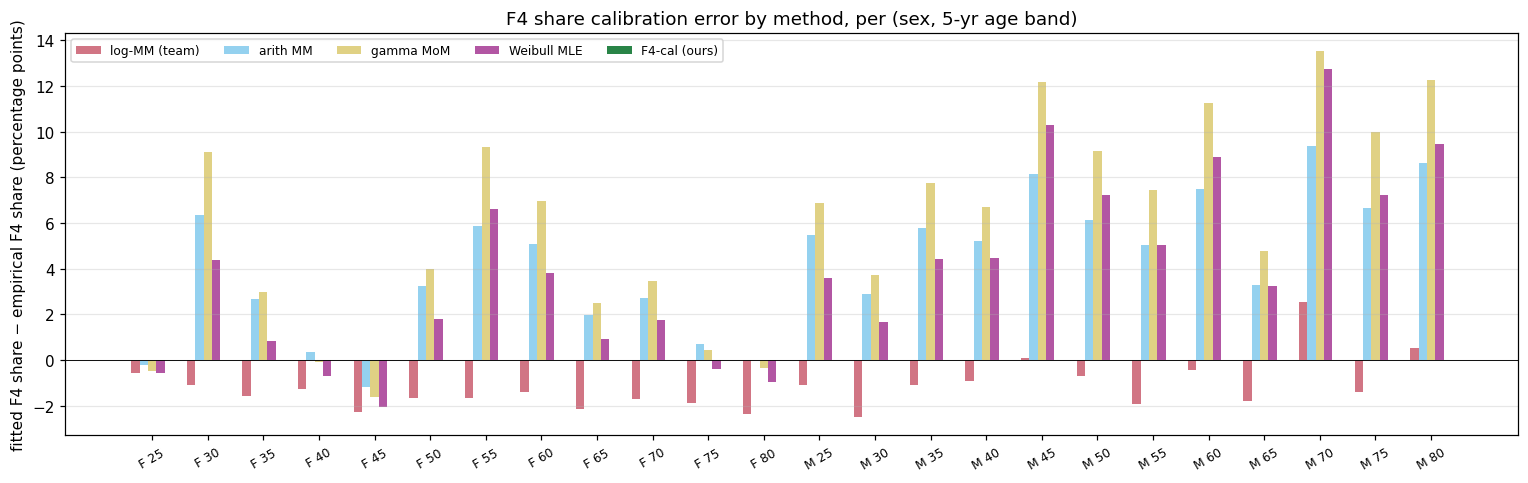

In [5]:
fs = fits.sort_values(['sex','age5']).reset_index(drop=True)
labels = [f"{r['sex'][:1]} {r['age5']}" for _, r in fs.iterrows()]
x = np.arange(len(fs))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 4.5))
for i, (col, lab, c) in enumerate([
    ('f4_logMM',  'log-MM (team)',  '#cc6677'),
    ('f4_aMM',    'arith MM',       '#88ccee'),
    ('f4_gamma',  'gamma MoM',      '#ddcc77'),
    ('f4_weib',   'Weibull MLE',    '#aa4499'),
    ('f4_F4',     'F4-cal (ours)',  '#117733'),
]):
    err = 100 * (fs[col] - fs['f4_emp'])
    ax.bar(x + (i - 2) * width, err, width, color=c, label=lab, alpha=0.9)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, fontsize=8)
ax.set_ylabel('fitted F4 share − empirical F4 share (percentage points)')
ax.set_title('F4 share calibration error by method, per (sex, 5-yr age band)')
ax.legend(loc='upper left', fontsize=8, ncols=5)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout(); plt.show()


## 6. Bulk-shape goodness of fit — KS distance

If F4-cal pins the tail and the others pin the bulk, F4-cal should pay for the tail accuracy in worse KS distance on the bulk. Quantify that here. Smaller is better.


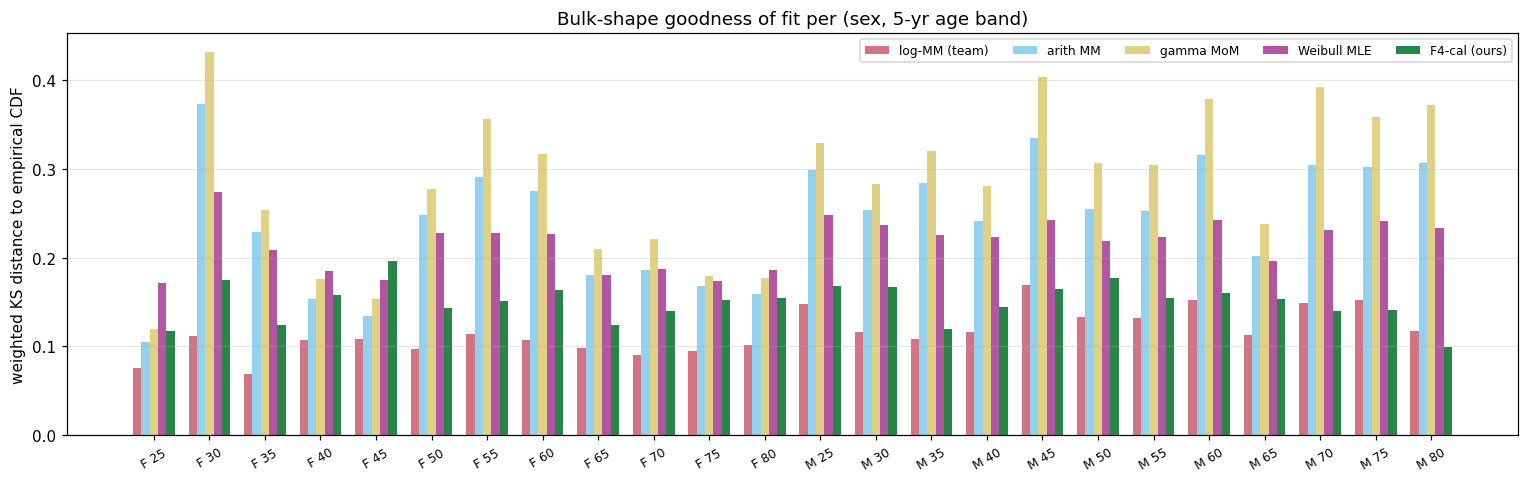

In [6]:
fig, ax = plt.subplots(figsize=(14, 4.5))
for i, (col, lab, c) in enumerate([
    ('ks_logMM',  'log-MM (team)',  '#cc6677'),
    ('ks_aMM',    'arith MM',       '#88ccee'),
    ('ks_gamma',  'gamma MoM',      '#ddcc77'),
    ('ks_weib',   'Weibull MLE',    '#aa4499'),
    ('ks_F4',     'F4-cal (ours)',  '#117733'),
]):
    ax.bar(x + (i - 2) * width, fs[col], width, color=c, label=lab, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, fontsize=8)
ax.set_ylabel('weighted KS distance to empirical CDF')
ax.set_title('Bulk-shape goodness of fit per (sex, 5-yr age band)')
ax.legend(loc='upper right', fontsize=8, ncols=5)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout(); plt.show()


## 7. CDF small multiples — eyeball test per cell

The plots above summarise; this is the per-cell picture. Empirical weighted CDF in black; each fit overlaid. Red dotted vertical line is the F4 cutoff at 12.5 kPa — that's where the F4-calibrated line crosses the empirical line by construction.


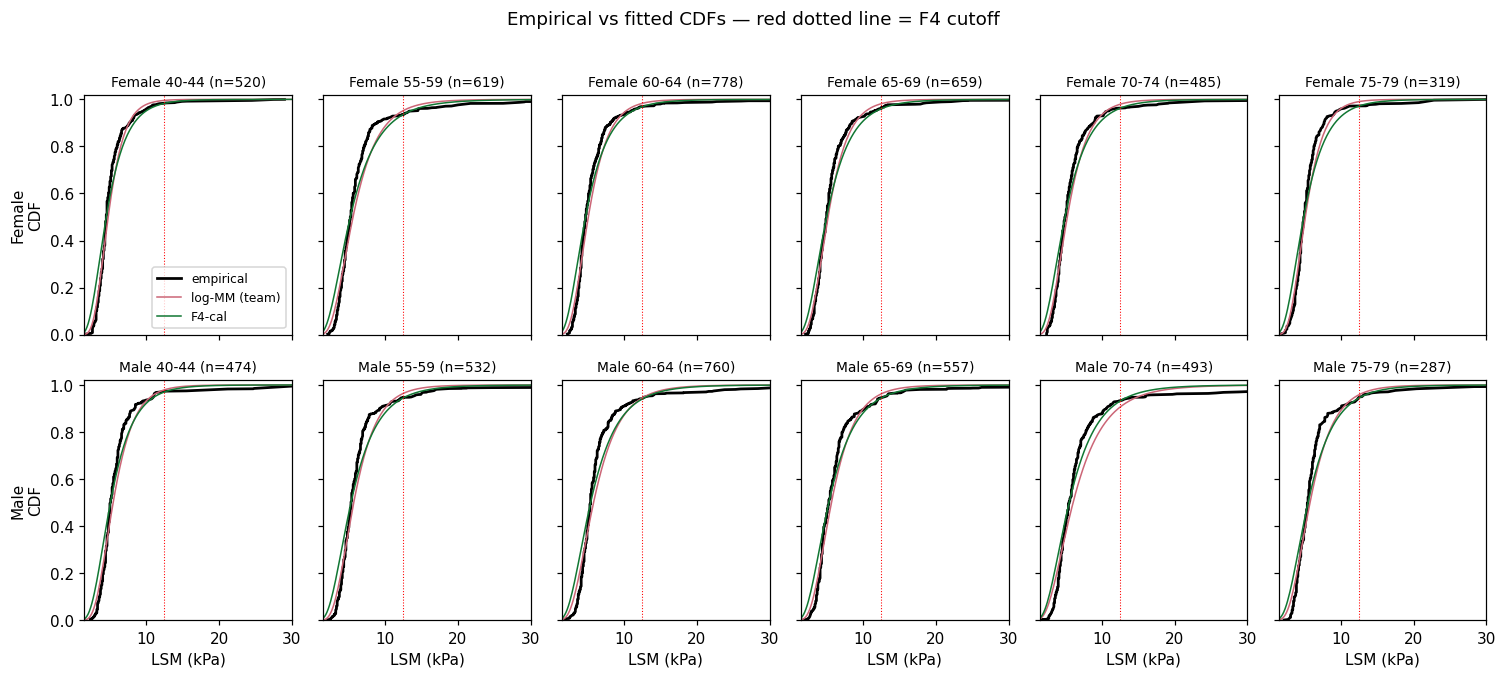

In [7]:
ages_to_show = [40, 55, 60, 65, 70, 75]
n_cols = len(ages_to_show)
fig, axes = plt.subplots(2, n_cols, figsize=(2.3 * n_cols, 6), sharex=True, sharey=True)
for i, sex in enumerate(['Female', 'Male']):
    for j, age5 in enumerate(ages_to_show):
        ax = axes[i, j]
        sub = ana[(ana['sex'] == sex)
                  & (ana['age_years'] >= age5)
                  & (ana['age_years'] < age5 + 5)]
        if len(sub) < 30:
            ax.set_axis_off(); continue
        y = sub['LSM_KPA'].values.astype(float)
        w = sub['MEC_WT_POOL'].values.astype(float)
        o = np.argsort(y); ys, ws = y[o], w[o]
        emp_cdf = np.cumsum(ws) / ws.sum()
        ax.plot(ys, emp_cdf, color='black', linewidth=1.8, label='empirical')

        f = fits[(fits['sex'] == sex) & (fits['age5'] == age5)].iloc[0]
        grid = np.linspace(1.5, 35, 200)
        ax.plot(grid, stats.lognorm.cdf(grid, f['sg_logMM'], scale=np.exp(f['mu_logMM'])),
                color='#cc6677', linewidth=1.0, label='log-MM (team)')
        if not np.isnan(f['sg_F4']):
            ax.plot(grid, stats.lognorm.cdf(grid, f['sg_F4'], scale=np.exp(f['mu_F4'])),
                    color='#117733', linewidth=1.0, label='F4-cal')
        ax.axvline(F4, color='red', linestyle=':', linewidth=0.7)
        ax.set_title(f'{sex} {age5}-{age5+4} (n={int(f["n"])})', fontsize=9)
        ax.set_xlim(1.5, 30); ax.set_ylim(0.0, 1.02)
        if j == 0: ax.set_ylabel(f'{sex}\nCDF')
        if i == 1: ax.set_xlabel('LSM (kPa)')
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Empirical vs fitted CDFs — red dotted line = F4 cutoff', y=1.02)
fig.tight_layout(); plt.show()


## 8. Why this matters for the simulation

In the project, an LSM ≥ 12.5 kPa simulant is routed to the **cirrhosis** excess-mortality rate; everyone else is routed to **MASLD** excess-mortality rate. The fraction of simulants in each route is essentially the F4 share predicted by the LSM distribution.

On the pooled NHANES sample, the team member's log-MM lognormal misses the empirical F4 share by these amounts in the trial-enrolment ages (table in the next cell shows all eight):
- Female 65-69: implied F4 ≈ 1.9 % vs empirical 4.0 % → **under-routes by 2.1 pp**
- Female 75-79: implied F4 ≈ 0.9 % vs empirical 2.8 % → **under-routes by 1.9 pp**
- Male 65-69: implied F4 ≈ 3.8 % vs empirical 5.6 % → **under-routes by 1.8 pp**
- Male 70-74: implied F4 ≈ 9.4 % vs empirical 6.8 % → **over-routes by 2.6 pp**

A 2-3 pp routing error per cell shifts a non-trivial share of person-time onto the wrong excess-mortality rate — and these are exactly the cells the trial enrols. F4 calibration eliminates this routing error by construction.

The trade-off: F4-cal lets the bulk drift. The CDF small-multiples show how big that drift is. The KS distance plot quantifies it: F4-cal often has a comparable or smaller KS than the alternatives because anchoring the median + tail is a strong constraint on the whole shape; it's not a free-lunch story but it's a favourable one on this data.


In [8]:
overlap = [(s, a) for s in ['Female','Male'] for a in [60, 65, 70, 75]]
summary = []
for s, a in overlap:
    f = fits[(fits['sex'] == s) & (fits['age5'] == a)].iloc[0]
    summary.append({
        'sex': s, 'age5': a,
        'f4_empirical': f['f4_emp'],
        'f4_team_logMM': f['f4_logMM'],
        'f4_F4cal_ours': f['f4_F4'],
        'logMM_err_pp':  100 * (f['f4_logMM'] - f['f4_emp']),
        'F4cal_err_pp':  100 * (f['f4_F4'] - f['f4_emp']),
    })
print('Routing error (cirrhosis vs MASLD) per cell, both methods:')
print(pd.DataFrame(summary).round(3).to_string(index=False))


Routing error (cirrhosis vs MASLD) per cell, both methods:
   sex  age5  f4_empirical  f4_team_logMM  f4_F4cal_ours  logMM_err_pp  F4cal_err_pp
Female    60         0.031          0.017          0.031        -1.400          -0.0
Female    65         0.040          0.019          0.040        -2.140          -0.0
Female    70         0.038          0.021          0.038        -1.705          -0.0
Female    75         0.028          0.009          0.028        -1.883          -0.0
  Male    60         0.059          0.055          0.059        -0.432          -0.0
  Male    65         0.056          0.038          0.056        -1.774           0.0
  Male    70         0.068          0.094          0.068         2.559           0.0
  Male    75         0.055          0.042          0.055        -1.377           0.0


## 9. What we put in the simulation

The strict loader consumes `liver_stiffness_age_sex_lognormal.csv` — that's the table notebook 04 produced (P_LUX adults 60+) and notebook 05 extended over the GBD skeleton. The columns:

- `mean_kpa`, `sd_kpa` — arithmetic moments of the **F4-calibrated lognormal**, back-transformed from (µ_F4, σ_F4)
- `f4_share_target` — the empirical F4 share the loader is targeting (informational, not consumed)

Compare to the team member's CSV which records (`LSM`, `LSM_sd`) = (µ, σ) of the **log-MM lognormal** directly. The team member's CSV is internally consistent and reproduces well from pooled NHANES, but it doesn't anchor F4 share, so it would route incorrectly in the oldest male cells.

**Open questions for the team:**

1. Should we switch to the pooled NHANES P_LUX + LUX_L sample (more N per cell, especially at 80+)? The team member's table uses it; ours doesn't. Notebook 04's F4-cal logic doesn't care which sample feeds it, so this is a low-cost upgrade.
2. The F4 share is noisy in cells where empirical F4 count is small (e.g., Female 70-74 had only ~3 F4 simulants among n=225 in P_LUX). Should we smooth across age within sex before calibrating?
3. The trial enrols 65-80 only. We forward-fill the sub-60 rows; is the team comfortable with this, or should we fit those age bands too (notebook 04 currently doesn't, on the rationale that the trial doesn't enrol them)?
